In [46]:
!source /home/devarsh/Work/deeplearning/.venv/bin/activate

In [47]:
!pip install pandas
!pip install matplotlib
!pip install -U scikit-learn

In [48]:
# Core imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [51]:
# ── UPDATE THIS PATH to where your data.csv lives ──
CSV_PATH = 'data.csv'

df = pd.read_csv(CSV_PATH)

# Keep only the two required columns
df = df[['Filename', 'AQI_Class']].copy()

print(f"Total samples: {len(df)}")
print(f"\nClass distribution:\n{df['AQI_Class'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Total samples: 6000

Class distribution:
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64

Missing values:
Filename     0
AQI_Class    0
dtype: int64


,Filename,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good


In [53]:
# ── UPDATE: base folder where sampled_images/ lives ──
IMAGE_BASE = 'sampled_images-20260313T112758Z-3-001/sampled_images'

def path_exists(rel_path):
    return os.path.exists(os.path.join(IMAGE_BASE, rel_path))

df['path_valid'] = df['Filename'].apply(path_exists)

print(f"Valid paths   : {df['path_valid'].sum()}")
print(f"Broken paths  : {(~df['path_valid']).sum()}")

# Drop rows with broken paths
df = df[df['path_valid']].drop(columns='path_valid').reset_index(drop=True)
print(f"\nClean dataset size: {len(df)}")

Valid paths   : 6000
Broken paths  : 0

Clean dataset size: 6000


In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['AQI_Class'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

NUM_CLASSES = len(le.classes_)
print(f"\nTotal classes: {NUM_CLASSES}")

Label mapping:
  0 → a_Good
  1 → b_Moderate
  2 → c_Unhealthy_for_Sensitive_Groups
  3 → d_Unhealthy
  4 → e_Very_Unhealthy
  5 → f_Severe

Total classes: 6


In [55]:
# Step 1: split off 70% train, 30% temp
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label']
)

# Step 2: split temp equally → 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df)} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")

Train : 4200 samples (70.0%)
Val   : 900 samples (15.0%)
Test  : 900 samples (15.0%)


In [57]:
IMG_SIZE = (224, 224)

def load_image(rel_path, base=IMAGE_BASE, size=IMG_SIZE):
    """Load → resize → normalize a single image."""
    full_path = os.path.join(base, rel_path)
    img = Image.open(full_path).convert('RGB')   # force 3-channel
    img = img.resize(size, Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr

# Quick sanity check
sample = load_image(train_df['Filename'][0])
print(f"Image shape : {sample.shape}")       # (224, 224, 3)
print(f"Pixel range : [{sample.min():.2f}, {sample.max():.2f}]")

Image shape : (224, 224, 3)
Pixel range : [0.10, 0.90]


In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':   
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [66]:
class AQIDataset(Dataset):
    def __init__(self, dataframe, base_path, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rel_path = self.df.loc[idx, 'Filename']
        label    = self.df.loc[idx, 'label']

        full_path = os.path.join(self.base_path, rel_path)
        image = Image.open(full_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

print("✅ AQIDataset class defined")

✅ AQIDataset class defined


In [67]:
IMG_SIZE = 224

# ImageNet mean/std — standard normalization values
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),                        # HWC → CHW, [0,255]→[0,1]
    transforms.Normalize(mean=MEAN, std=STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print("✅ Transforms defined")

✅ Transforms defined


In [68]:
BATCH_SIZE = 32

train_dataset = AQIDataset(train_df, IMAGE_BASE, transform=train_transform)
val_dataset   = AQIDataset(val_df,   IMAGE_BASE, transform=val_test_transform)
test_dataset  = AQIDataset(test_df,  IMAGE_BASE, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
                          

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Verify one batch shape
imgs, labels = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")    # [32, 3, 224, 224]
print(f"Batch label shape : {labels.shape}")   # [32]

Train batches : 132
Val   batches : 29
Test  batches : 29

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])


In [69]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()

        # ── Block 1: 3 → 32 channels ──────────────────────────
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # same padding
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # 224 → 112
            nn.Dropout2d(0.25)
        )

        # ── Block 2: 32 → 64 channels ─────────────────────────
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # 112 → 56
            nn.Dropout2d(0.25)
        )

        # ── Block 3: 64 → 128 channels ────────────────────────
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # 56 → 28
            nn.Dropout2d(0.25)
        )

        # ── Classifier head ───────────────────────────────────
        self.pool = nn.AdaptiveAvgPool2d((1, 1))           # 28 → 1×1

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


# Instantiate & inspect
model_cnn = BasicCNN(num_classes=NUM_CLASSES).to(device)

# Count trainable parameters
total_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model_cnn)

Trainable parameters: 322,470
BasicCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPoo

In [70]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("✅ Loss / Optimizer / Scheduler ready")

✅ Loss / Optimizer / Scheduler ready


In [71]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds        = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, correct / total


print("✅ Train / Eval functions defined")

✅ Train / Eval functions defined


In [73]:
EPOCHS = 25

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_acc  = 0.0
best_model_path = 'best_basic_cnn.pth'

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model_cnn, train_loader, criterion, optimizer, device)

    val_loss, val_acc = evaluate(
        model_cnn, val_loader, criterion, device)

    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Checkpoint best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_cnn.state_dict(), best_model_path)
        tag = " ← best"
    else:
        tag = ""

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%{tag}")

print(f"\n✅ Training complete — Best Val Acc: {best_val_acc*100:.2f}%")

Epoch [01/25] Train Loss: 1.5515  Acc: 36.36%  | Val Loss: 1.3643  Acc: 44.89% ← best
Epoch [02/25] Train Loss: 1.4704  Acc: 41.00%  | Val Loss: 1.3458  Acc: 44.89%
Epoch [03/25] Train Loss: 1.3944  Acc: 44.74%  | Val Loss: 1.1841  Acc: 53.67% ← best
Epoch [04/25] Train Loss: 1.3536  Acc: 46.60%  | Val Loss: 1.2065  Acc: 51.33%
Epoch [05/25] Train Loss: 1.3154  Acc: 47.26%  | Val Loss: 1.1540  Acc: 54.78% ← best
Epoch [06/25] Train Loss: 1.3020  Acc: 49.43%  | Val Loss: 1.1820  Acc: 53.00%
Epoch [07/25] Train Loss: 1.2387  Acc: 51.29%  | Val Loss: 1.0318  Acc: 62.00% ← best
Epoch [08/25] Train Loss: 1.2202  Acc: 51.62%  | Val Loss: 1.0088  Acc: 61.67%
Epoch [09/25] Train Loss: 1.2003  Acc: 52.29%  | Val Loss: 1.0153  Acc: 61.67%
Epoch [10/25] Train Loss: 1.1939  Acc: 52.76%  | Val Loss: 0.9978  Acc: 63.89% ← best
Epoch [11/25] Train Loss: 1.1709  Acc: 54.29%  | Val Loss: 0.9864  Acc: 63.78%
Epoch [12/25] Train Loss: 1.1888  Acc: 52.24%  | Val Loss: 1.0074  Acc: 61.33%
Epoch [13/25] Tra

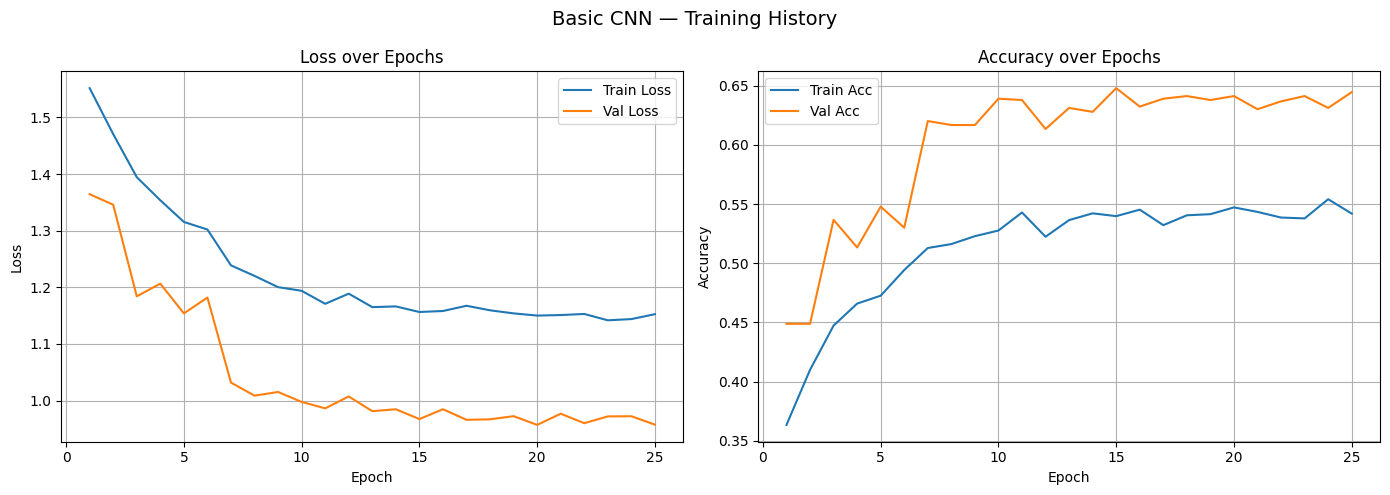

In [75]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

# Accuracy
ax2.plot(epochs_range, history['train_acc'], label='Train Acc')
ax2.plot(epochs_range, history['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True)

plt.suptitle('Basic CNN — Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [77]:
!pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.0 MB/s eta 0:00:00a 0:00:01


         BASIC CNN — TEST SET RESULTS
                                  precision    recall  f1-score   support

                          a_Good       0.63      0.49      0.55       150
                      b_Moderate       0.55      0.49      0.52       150
c_Unhealthy_for_Sensitive_Groups       0.46      0.28      0.35       150
                     d_Unhealthy       0.50      0.75      0.60       150
                e_Very_Unhealthy       0.85      0.67      0.75       150
                        f_Severe       0.68      0.98      0.80       150

                        accuracy                           0.61       900
                       macro avg       0.61      0.61      0.60       900
                    weighted avg       0.61      0.61      0.60       900



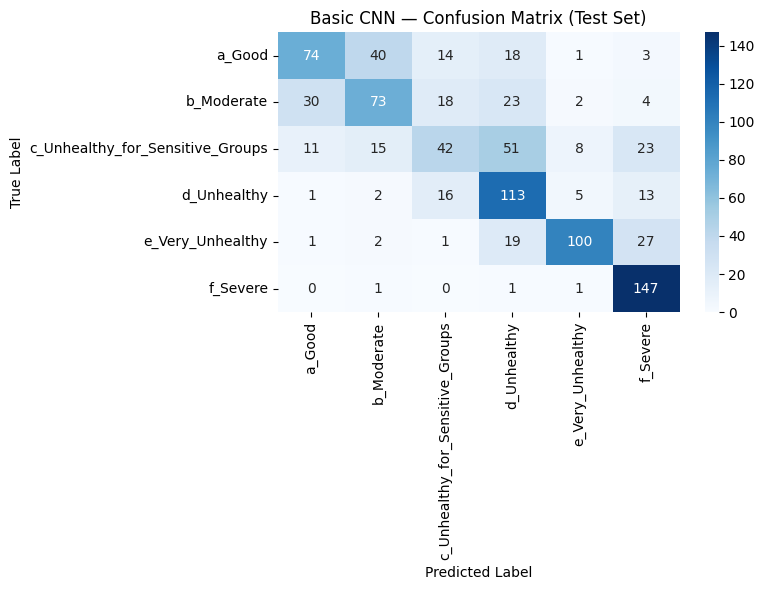

In [78]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best weights
model_cnn.load_state_dict(torch.load(best_model_path, map_location=device))
model_cnn.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_cnn(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Classification Report ──────────────────────────────────────
print("=" * 60)
print("         BASIC CNN — TEST SET RESULTS")
print("=" * 60)
print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_
))

# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Basic CNN — Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Task 3 – Pretrained CNN Model (Transfer Learning)
 - Use a pretrained model such as ResNet, VGG, or EfficientNet.
 - Replace the final classification layer to match the number of AQI classes.
 - Train the model using transfer learning.
 - Compare performance with the basic CNN model.

In [79]:
from torchvision import models

# Load pretrained EfficientNet-B0
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Inspect the final classifier layer
print(effnet.classifier)
print(f"\nOriginal output features: {effnet.classifier[1].out_features}")

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Original output features: 1000


In [80]:
import torch.nn as nn

# Get the input features of the existing classifier
in_features = effnet.classifier[1].in_features
print(f"Input features to classifier: {in_features}")

# Replace final layer with our own
effnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)
)

# Move to GPU
model_tl = effnet.to(device)

# Count parameters
total_params     = sum(p.numel() for p in model_tl.parameters())
trainable_params = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)

print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"\nNew classifier head:\n{model_tl.classifier}")

Input features to classifier: 1280

Total parameters     : 4,015,234
Trainable parameters : 4,015,234

New classifier head:
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


In [81]:
# Freeze all layers except the classifier
for name, param in model_tl.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

# Verify
frozen     = sum(p.numel() for p in model_tl.parameters() if not p.requires_grad)
trainable  = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)

print(f"Frozen parameters    : {frozen:,}")
print(f"Trainable parameters : {trainable:,}")
print("\n✅ Backbone frozen — only classifier head will train")

Frozen parameters    : 4,007,548
Trainable parameters : 7,686

✅ Backbone frozen — only classifier head will train


In [82]:
# Phase 1: train only the classifier head
criterion_tl  = nn.CrossEntropyLoss()

optimizer_tl  = optim.Adam(
    filter(lambda p: p.requires_grad, model_tl.parameters()),
    lr=1e-3
)

scheduler_tl  = optim.lr_scheduler.StepLR(optimizer_tl, step_size=3, gamma=0.5)

print("✅ Phase 1 — Optimizer & Scheduler ready")

✅ Phase 1 — Optimizer & Scheduler ready


In [83]:
PHASE1_EPOCHS = 5

history_tl = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}

best_val_acc_tl  = 0.0
best_model_path_tl = 'best_transfer_model.pth'

print("=" * 65)
print("PHASE 1 — Training classifier head only")
print("=" * 65)

for epoch in range(1, PHASE1_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model_tl, train_loader, criterion_tl, optimizer_tl, device)

    val_loss, val_acc = evaluate(
        model_tl, val_loader, criterion_tl, device)

    scheduler_tl.step()

    history_tl['train_loss'].append(train_loss)
    history_tl['val_loss'].append(val_loss)
    history_tl['train_acc'].append(train_acc)
    history_tl['val_acc'].append(val_acc)

    if val_acc > best_val_acc_tl:
        best_val_acc_tl = val_acc
        torch.save(model_tl.state_dict(), best_model_path_tl)
        tag = " ← best"
    else:
        tag = ""

    print(f"Epoch [{epoch:02d}/{PHASE1_EPOCHS}] "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%{tag}")

print(f"\n✅ Phase 1 complete — Best Val Acc: {best_val_acc_tl*100:.2f}%")

PHASE 1 — Training classifier head only
Epoch [01/5] Train Loss: 1.3641  Acc: 48.38%  | Val Loss: 1.0661  Acc: 62.22% ← best
Epoch [02/5] Train Loss: 1.0667  Acc: 60.86%  | Val Loss: 0.9177  Acc: 68.22% ← best
Epoch [03/5] Train Loss: 0.9611  Acc: 63.67%  | Val Loss: 0.8359  Acc: 69.33% ← best
Epoch [04/5] Train Loss: 0.9118  Acc: 66.60%  | Val Loss: 0.7958  Acc: 70.11% ← best
Epoch [05/5] Train Loss: 0.8668  Acc: 68.36%  | Val Loss: 0.7837  Acc: 70.22% ← best

✅ Phase 1 complete — Best Val Acc: 70.22%


In [84]:
# Unfreeze ALL layers
for param in model_tl.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
print(f"All layers unfrozen — Trainable parameters: {trainable:,}")

# Phase 2: very low LR for backbone, normal LR for head
optimizer_tl2 = optim.Adam([
    {'params': model_tl.features.parameters(),    'lr': 1e-5},  # backbone — tiny LR
    {'params': model_tl.classifier.parameters(),  'lr': 1e-4},  # head — small LR
])

scheduler_tl2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_tl2, T_max=10, eta_min=1e-7
)

print("✅ Phase 2 — Optimizer & Scheduler ready")

All layers unfrozen — Trainable parameters: 4,015,234
✅ Phase 2 — Optimizer & Scheduler ready


In [85]:
PHASE2_EPOCHS = 15

print("=" * 65)
print("PHASE 2 — Fine-tuning entire network")
print("=" * 65)

for epoch in range(1, PHASE2_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model_tl, train_loader, criterion_tl, optimizer_tl2, device)

    val_loss, val_acc = evaluate(
        model_tl, val_loader, criterion_tl, device)

    scheduler_tl2.step()

    history_tl['train_loss'].append(train_loss)
    history_tl['val_loss'].append(val_loss)
    history_tl['train_acc'].append(train_acc)
    history_tl['val_acc'].append(val_acc)

    if val_acc > best_val_acc_tl:
        best_val_acc_tl = val_acc
        torch.save(model_tl.state_dict(), best_model_path_tl)
        tag = " ← best"
    else:
        tag = ""

    print(f"Epoch [{epoch:02d}/{PHASE2_EPOCHS}] "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%{tag}")

print(f"\n✅ Phase 2 complete — Best Val Acc: {best_val_acc_tl*100:.2f}%")

PHASE 2 — Fine-tuning entire network
Epoch [01/15] Train Loss: 0.8258  Acc: 70.07%  | Val Loss: 0.7020  Acc: 72.44% ← best
Epoch [02/15] Train Loss: 0.7342  Acc: 73.43%  | Val Loss: 0.6192  Acc: 77.67% ← best
Epoch [03/15] Train Loss: 0.6775  Acc: 75.21%  | Val Loss: 0.5698  Acc: 79.89% ← best
Epoch [04/15] Train Loss: 0.6278  Acc: 77.02%  | Val Loss: 0.5245  Acc: 81.67% ← best
Epoch [05/15] Train Loss: 0.5959  Acc: 79.17%  | Val Loss: 0.4887  Acc: 82.89% ← best
Epoch [06/15] Train Loss: 0.5674  Acc: 80.05%  | Val Loss: 0.4800  Acc: 83.33% ← best
Epoch [07/15] Train Loss: 0.5364  Acc: 81.50%  | Val Loss: 0.4521  Acc: 85.11% ← best
Epoch [08/15] Train Loss: 0.5237  Acc: 81.88%  | Val Loss: 0.4374  Acc: 84.44%
Epoch [09/15] Train Loss: 0.5272  Acc: 81.79%  | Val Loss: 0.4439  Acc: 85.11%
Epoch [10/15] Train Loss: 0.5227  Acc: 81.81%  | Val Loss: 0.4369  Acc: 84.67%
Epoch [11/15] Train Loss: 0.5211  Acc: 82.29%  | Val Loss: 0.4385  Acc: 84.78%
Epoch [12/15] Train Loss: 0.5072  Acc: 82.79%

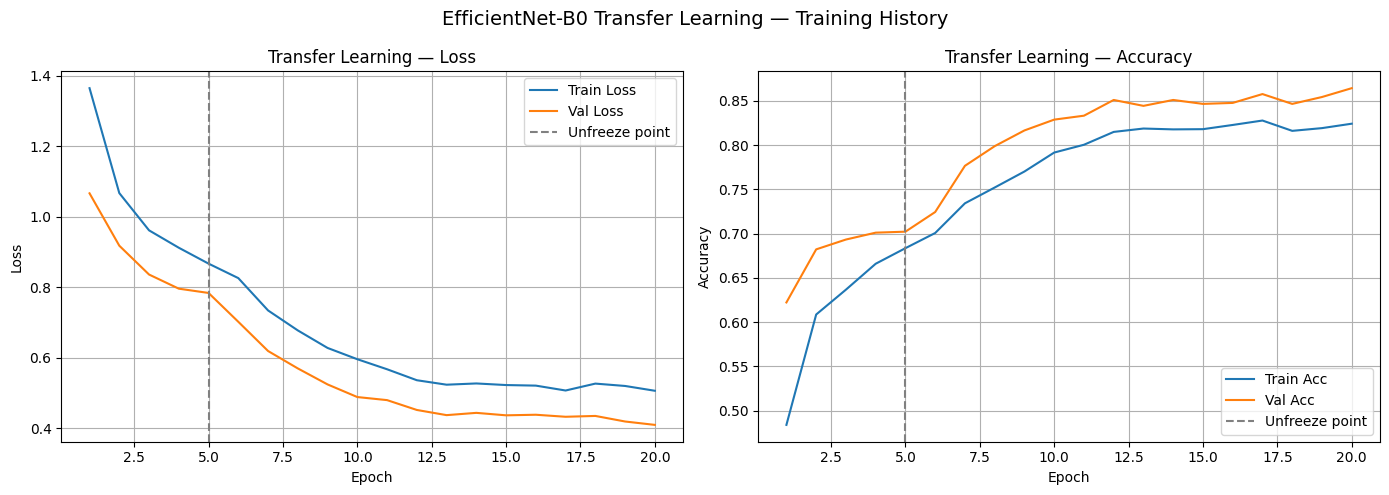

In [88]:
total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS
epochs_range = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, history_tl['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history_tl['val_loss'],   label='Val Loss')
ax1.axvline(x=PHASE1_EPOCHS, color='gray', linestyle='--', label='Unfreeze point')
ax1.set_title('Transfer Learning — Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

# Accuracy
ax2.plot(epochs_range, history_tl['train_acc'], label='Train Acc')
ax2.plot(epochs_range, history_tl['val_acc'],   label='Val Acc')
ax2.axvline(x=PHASE1_EPOCHS, color='gray', linestyle='--', label='Unfreeze point')
ax2.set_title('Transfer Learning — Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True)

plt.suptitle('EfficientNet-B0 Transfer Learning — Training History', fontsize=14)
plt.tight_layout()
plt.show()

   EFFICIENTNET-B0 — TEST SET RESULTS
                                  precision    recall  f1-score   support

                          a_Good       0.85      0.77      0.81       150
                      b_Moderate       0.70      0.87      0.77       150
c_Unhealthy_for_Sensitive_Groups       0.84      0.77      0.81       150
                     d_Unhealthy       0.86      0.83      0.84       150
                e_Very_Unhealthy       0.98      0.87      0.92       150
                        f_Severe       0.93      0.99      0.95       150

                        accuracy                           0.85       900
                       macro avg       0.86      0.85      0.85       900
                    weighted avg       0.86      0.85      0.85       900



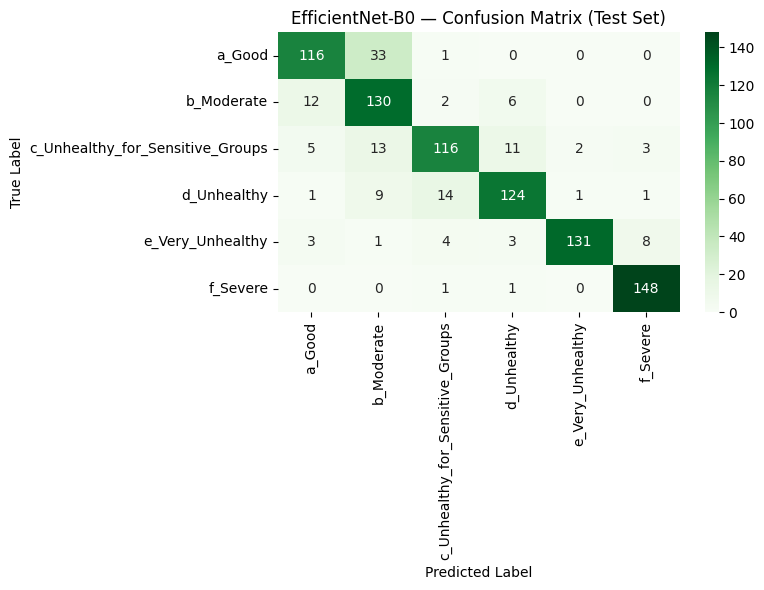

In [89]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best weights
model_tl.load_state_dict(torch.load(best_model_path_tl, map_location=device))
model_tl.eval()

all_preds_tl, all_labels_tl = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_tl(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds_tl.extend(preds)
        all_labels_tl.extend(labels.numpy())

all_preds_tl  = np.array(all_preds_tl)
all_labels_tl = np.array(all_labels_tl)

print("=" * 60)
print("   EFFICIENTNET-B0 — TEST SET RESULTS")
print("=" * 60)
print(classification_report(
    all_labels_tl, all_preds_tl,
    target_names=le.classes_
))

# Confusion Matrix
cm_tl = confusion_matrix(all_labels_tl, all_preds_tl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('EfficientNet-B0 — Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Metric                       Basic CNN EfficientNet
Test Accuracy                   61.00%       85.00%
Weighted F1 Score               0.5953       0.8510
Total Parameters               322,470    4,015,234
Train Epochs                        25           20


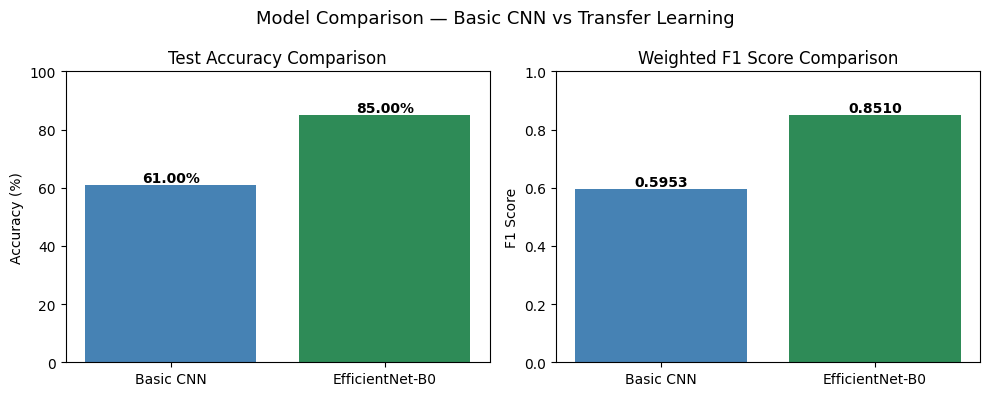

In [90]:
from sklearn.metrics import accuracy_score, f1_score

# Metrics for both models
cnn_acc = accuracy_score(all_labels,    all_preds)
tl_acc  = accuracy_score(all_labels_tl, all_preds_tl)

cnn_f1  = f1_score(all_labels,    all_preds,    average='weighted')
tl_f1   = f1_score(all_labels_tl, all_preds_tl, average='weighted')

cnn_params = sum(p.numel() for p in model_cnn.parameters())
tl_params  = sum(p.numel() for p in model_tl.parameters())

# Print comparison table
print("=" * 55)
print(f"{'Metric':<25} {'Basic CNN':>12} {'EfficientNet':>12}")
print("=" * 55)
print(f"{'Test Accuracy':<25} {cnn_acc*100:>11.2f}% {tl_acc*100:>11.2f}%")
print(f"{'Weighted F1 Score':<25} {cnn_f1:>12.4f} {tl_f1:>12.4f}")
print(f"{'Total Parameters':<25} {cnn_params:>12,} {tl_params:>12,}")
print(f"{'Train Epochs':<25} {25:>12} {PHASE1_EPOCHS+PHASE2_EPOCHS:>12}")
print("=" * 55)

# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

models      = ['Basic CNN', 'EfficientNet-B0']
accuracies  = [cnn_acc * 100, tl_acc * 100]
f1_scores   = [cnn_f1,        tl_f1]
colors      = ['steelblue',   'seagreen']

ax1.bar(models, accuracies, color=colors)
ax1.set_title('Test Accuracy Comparison')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 100)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')

ax2.bar(models, f1_scores, color=colors)
ax2.set_title('Weighted F1 Score Comparison')
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison — Basic CNN vs Transfer Learning', fontsize=13)
plt.tight_layout()
plt.show()

# Task 4 – Model Training and Evaluation
 - Evaluate models using:
 - Accuracy, Precision, Recall, F1-score
 - Generate a confusion matrix for the test dataset and compare performance between the
 - CNN model and the pretrained model.

In [91]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ── Basic CNN ─────────────────────────────────────────────────
model_cnn.load_state_dict(torch.load(best_model_path, map_location=device))
model_cnn.eval()

preds_cnn, labels_cnn = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_cnn(images)
        preds_cnn.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_cnn.extend(labels.numpy())

preds_cnn  = np.array(preds_cnn)
labels_cnn = np.array(labels_cnn)

# ── EfficientNet ──────────────────────────────────────────────
model_tl.load_state_dict(torch.load(best_model_path_tl, map_location=device))
model_tl.eval()

preds_tl, labels_tl = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_tl(images)
        preds_tl.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_tl.extend(labels.numpy())

preds_tl  = np.array(preds_tl)
labels_tl = np.array(labels_tl)

print(f"✅ Test samples evaluated: {len(labels_cnn)}")

✅ Test samples evaluated: 900


In [92]:
import pandas as pd

def metrics_dataframe(y_true, y_pred, class_names):
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True
    )
    rows = []
    for cls in class_names:
        rows.append({
            'Class'    : cls,
            'Precision': round(report[cls]['precision'], 4),
            'Recall'   : round(report[cls]['recall'],    4),
            'F1-Score' : round(report[cls]['f1-score'],  4),
            'Support'  : int(report[cls]['support'])
        })
    return pd.DataFrame(rows)


print("=" * 60)
print("         BASIC CNN — Per-Class Metrics")
print("=" * 60)
df_cnn_metrics = metrics_dataframe(labels_cnn, preds_cnn, le.classes_)
print(df_cnn_metrics.to_string(index=False))

print("\n")
print("=" * 60)
print("      EFFICIENTNET-B0 — Per-Class Metrics")
print("=" * 60)
df_tl_metrics = metrics_dataframe(labels_tl, preds_tl, le.classes_)
print(df_tl_metrics.to_string(index=False))

         BASIC CNN — Per-Class Metrics
                           Class  Precision  Recall  F1-Score  Support
                          a_Good     0.6325  0.4933    0.5543      150
                      b_Moderate     0.5489  0.4867    0.5159      150
c_Unhealthy_for_Sensitive_Groups     0.4615  0.2800    0.3485      150
                     d_Unhealthy     0.5022  0.7533    0.6027      150
                e_Very_Unhealthy     0.8547  0.6667    0.7491      150
                        f_Severe     0.6774  0.9800    0.8011      150


      EFFICIENTNET-B0 — Per-Class Metrics
                           Class  Precision  Recall  F1-Score  Support
                          a_Good     0.8467  0.7733    0.8084      150
                      b_Moderate     0.6989  0.8667    0.7738      150
c_Unhealthy_for_Sensitive_Groups     0.8406  0.7733    0.8056      150
                     d_Unhealthy     0.8552  0.8267    0.8407      150
                e_Very_Unhealthy     0.9776  0.8733    0.9225    

In [93]:
def overall_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred),                        4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'),   4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted'),      4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted'),          4),
    }

summary = pd.DataFrame([
    overall_metrics(labels_cnn, preds_cnn, 'Basic CNN'),
    overall_metrics(labels_tl,  preds_tl,  'EfficientNet-B0'),
])

print("=" * 60)
print("        OVERALL METRICS COMPARISON")
print("=" * 60)
print(summary.to_string(index=False))

        OVERALL METRICS COMPARISON
          Model  Accuracy  Precision  Recall  F1-Score
      Basic CNN      0.61     0.6129    0.61    0.5953
EfficientNet-B0      0.85     0.8573    0.85    0.8510


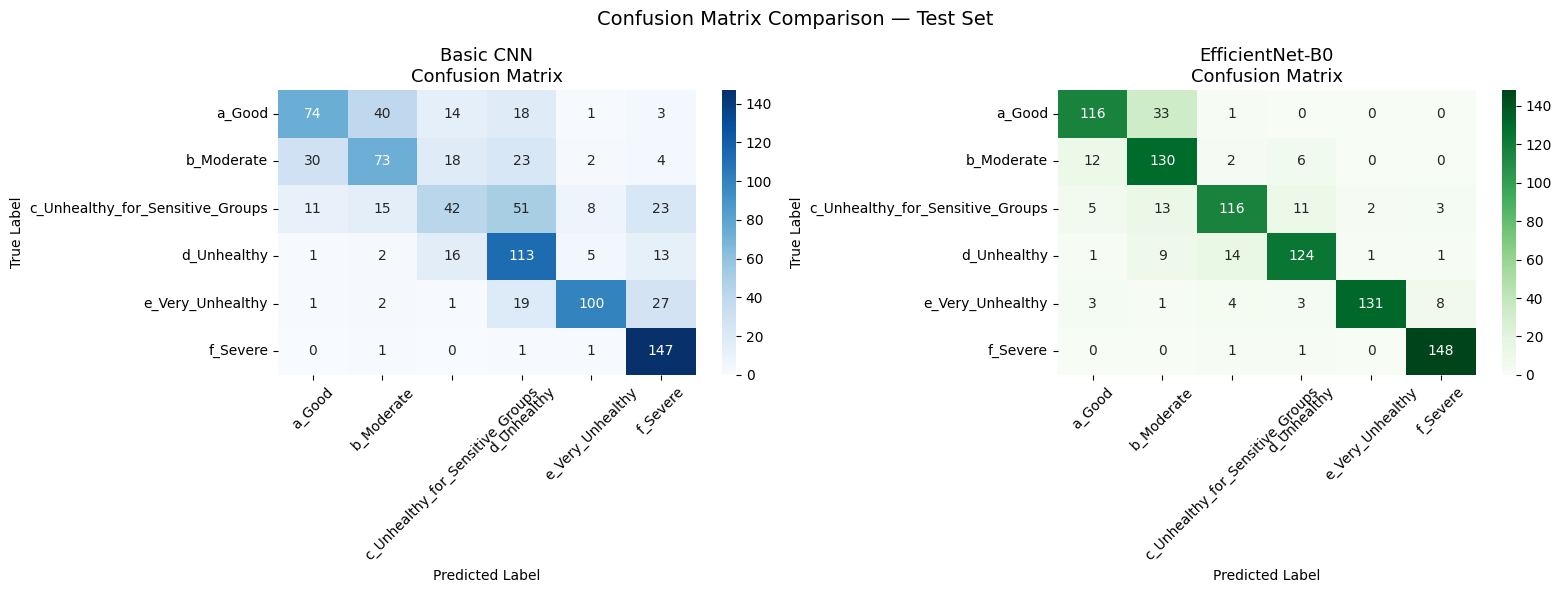

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_cnn = confusion_matrix(labels_cnn, preds_cnn)
cm_tl  = confusion_matrix(labels_tl,  preds_tl)

# Basic CNN
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=axes[0])
axes[0].set_title('Basic CNN\nConfusion Matrix', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# EfficientNet
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=axes[1])
axes[1].set_title('EfficientNet-B0\nConfusion Matrix', fontsize=13)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix Comparison — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

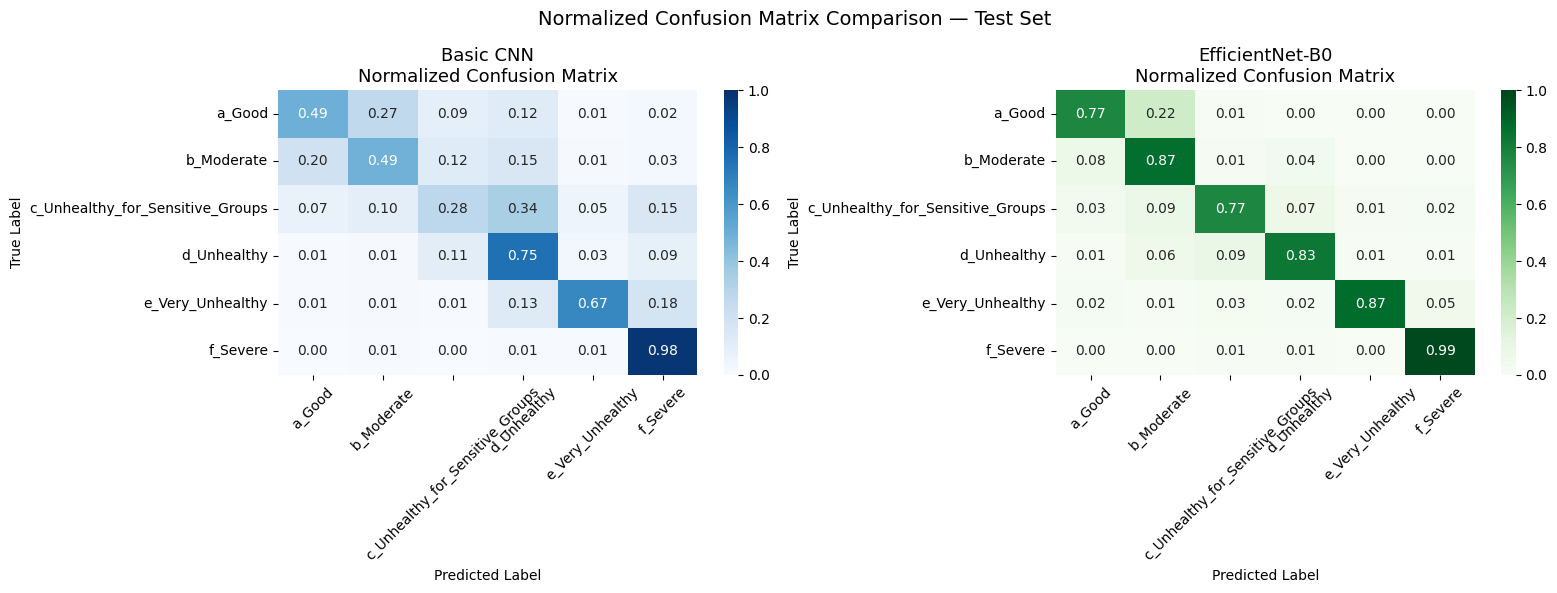

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_cnn_norm = cm_cnn.astype('float') / cm_cnn.sum(axis=1, keepdims=True)
cm_tl_norm  = cm_tl.astype('float')  / cm_tl.sum(axis=1,  keepdims=True)

sns.heatmap(cm_cnn_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Basic CNN\nNormalized Confusion Matrix', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_tl_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('EfficientNet-B0\nNormalized Confusion Matrix', fontsize=13)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Normalized Confusion Matrix Comparison — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

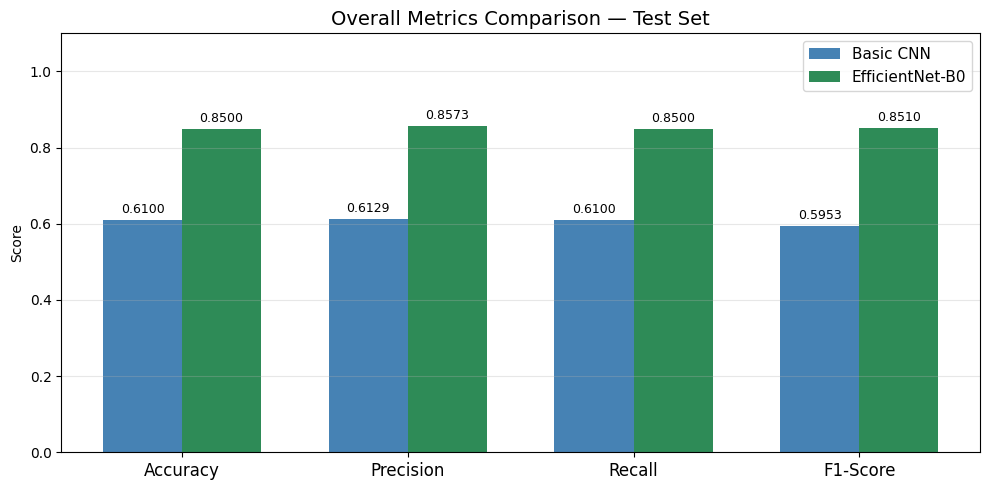

In [96]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_vals  = [summary.loc[0, m] for m in metrics]
tl_vals   = [summary.loc[1, m] for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, cnn_vals, width,
               label='Basic CNN',       color='steelblue')
bars2 = ax.bar(x + width/2, tl_vals,   width,
               label='EfficientNet-B0', color='seagreen')

ax.set_title('Overall Metrics Comparison — Test Set', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [97]:
print("=" * 60)
print("            FINAL EVALUATION SUMMARY")
print("=" * 60)

for _, row in summary.iterrows():
    print(f"\n  Model     : {row['Model']}")
    print(f"  Accuracy  : {row['Accuracy']*100:.2f}%")
    print(f"  Precision : {row['Precision']*100:.2f}%")
    print(f"  Recall    : {row['Recall']*100:.2f}%")
    print(f"  F1-Score  : {row['F1-Score']*100:.2f}%")
    print("  " + "-" * 35)

# Winner
best_model = summary.loc[summary['F1-Score'].idxmax(), 'Model']
best_f1    = summary['F1-Score'].max()
print(f"\n🏆 Best Model : {best_model}  (F1 = {best_f1*100:.2f}%)")
print("=" * 60)

            FINAL EVALUATION SUMMARY

  Model     : Basic CNN
  Accuracy  : 61.00%
  Precision : 61.29%
  Recall    : 61.00%
  F1-Score  : 59.53%
  -----------------------------------

  Model     : EfficientNet-B0
  Accuracy  : 85.00%
  Precision : 85.73%
  Recall    : 85.00%
  F1-Score  : 85.10%
  -----------------------------------

🏆 Best Model : EfficientNet-B0  (F1 = 85.10%)


# Task 5 – Training Curves
 - Plot the following graphs:
  - Epoch vs Training Loss, Validation Loss, Training Accuracy, Validation Accuracy
  - Discuss why pretrained models often outperform models trained from scratch and whether
    transfer learning helped in this dataset.

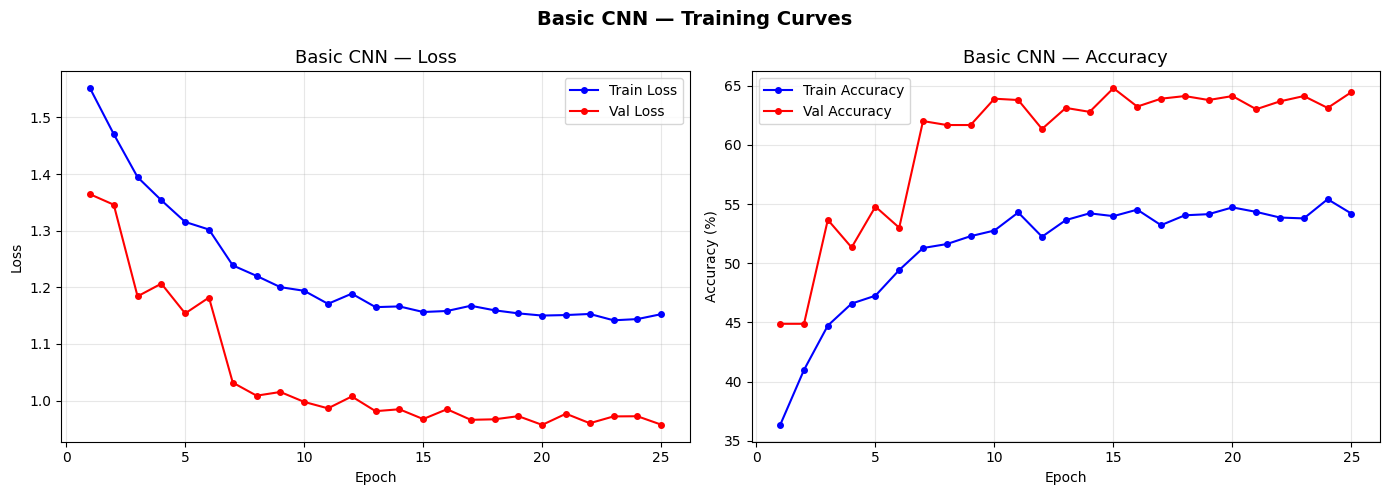

In [98]:
import matplotlib.pyplot as plt
import numpy as np

epochs_cnn = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_cnn, history['train_loss'], 
             'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_cnn, history['val_loss'],   
             'r-o', markersize=4, label='Val Loss')
axes[0].set_title('Basic CNN — Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_cnn, [a*100 for a in history['train_acc']],
             'b-o', markersize=4, label='Train Accuracy')
axes[1].plot(epochs_cnn, [a*100 for a in history['val_acc']],
             'r-o', markersize=4, label='Val Accuracy')
axes[1].set_title('Basic CNN — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Basic CNN — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

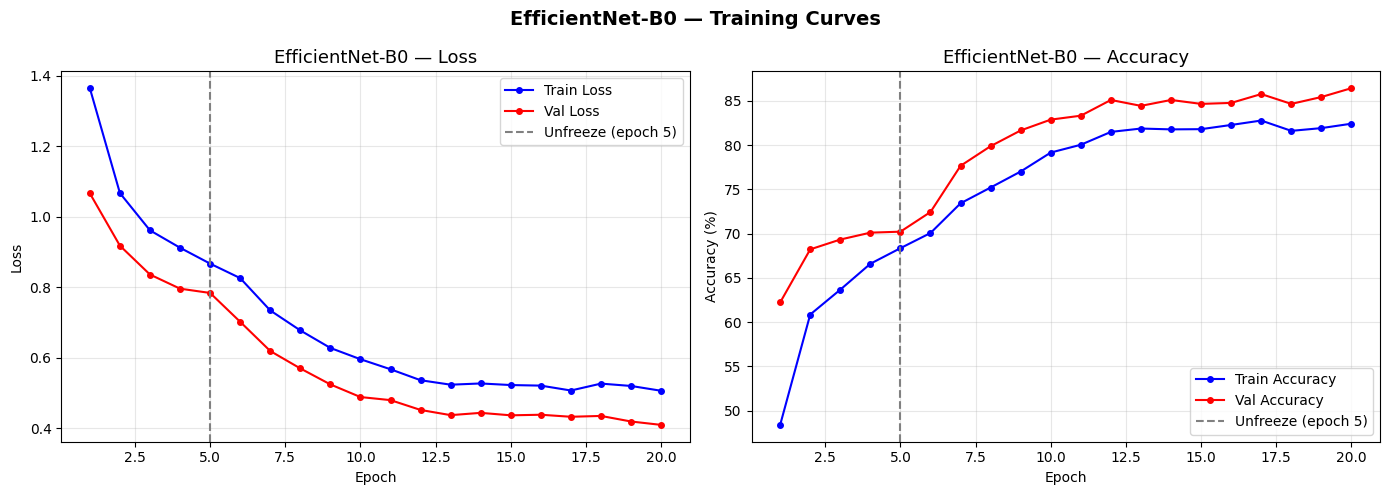

In [99]:
epochs_tl    = range(1, len(history_tl['train_loss']) + 1)
unfreeze_at  = PHASE1_EPOCHS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_tl, history_tl['train_loss'],
             'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_tl, history_tl['val_loss'],
             'r-o', markersize=4, label='Val Loss')
axes[0].axvline(x=unfreeze_at, color='gray',
                linestyle='--', linewidth=1.5, label=f'Unfreeze (epoch {unfreeze_at})')
axes[0].set_title('EfficientNet-B0 — Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_tl, [a*100 for a in history_tl['train_acc']],
             'b-o', markersize=4, label='Train Accuracy')
axes[1].plot(epochs_tl, [a*100 for a in history_tl['val_acc']],
             'r-o', markersize=4, label='Val Accuracy')
axes[1].axvline(x=unfreeze_at, color='gray',
                linestyle='--', linewidth=1.5, label=f'Unfreeze (epoch {unfreeze_at})')
axes[1].set_title('EfficientNet-B0 — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('EfficientNet-B0 — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

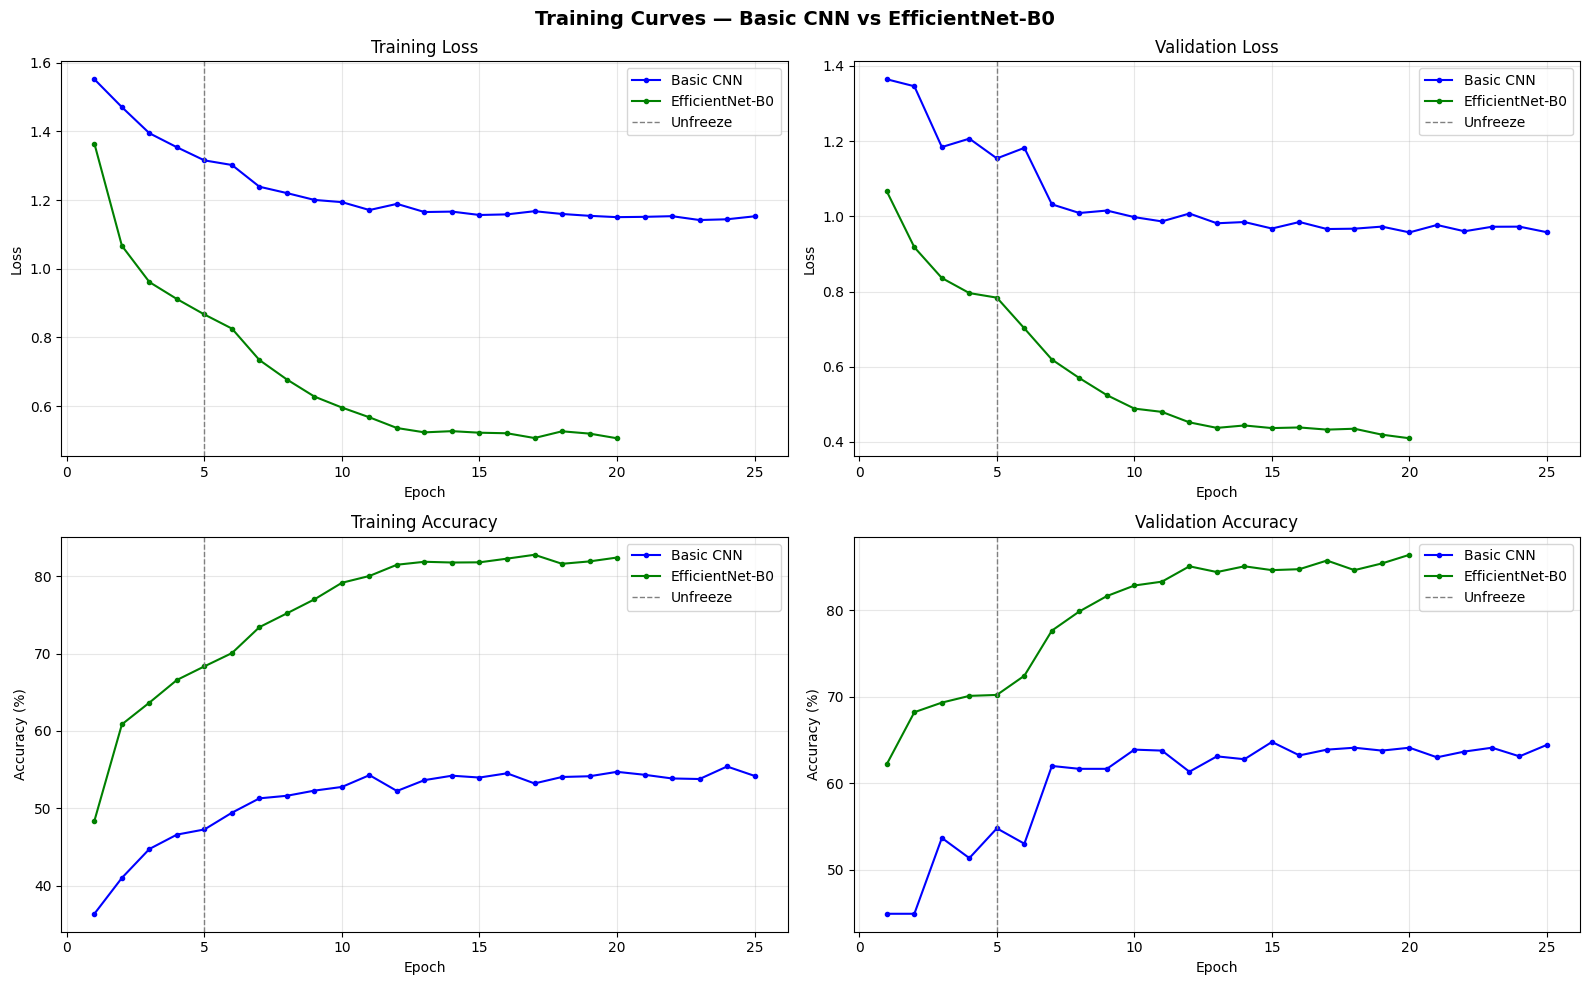

In [101]:
# Pad CNN history if lengths differ so both plot on same x axis
max_epochs = max(len(history['train_loss']), len(history_tl['train_loss']))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

e_cnn = range(1, len(history['train_loss'])    + 1)
e_tl  = range(1, len(history_tl['train_loss']) + 1)

# ── Train Loss ────────────────────────────────────────────────
axes[0,0].plot(e_cnn, history['train_loss'],    
               'b-o', markersize=3, label='Basic CNN')
axes[0,0].plot(e_tl,  history_tl['train_loss'], 
               'g-o', markersize=3, label='EfficientNet-B0')
axes[0,0].axvline(x=PHASE1_EPOCHS, color='gray',
                  linestyle='--', linewidth=1, label='Unfreeze')
axes[0,0].set_title('Training Loss', fontsize=12)
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# ── Validation Loss ───────────────────────────────────────────
axes[0,1].plot(e_cnn, history['val_loss'],
               'b-o', markersize=3, label='Basic CNN')
axes[0,1].plot(e_tl,  history_tl['val_loss'],
               'g-o', markersize=3, label='EfficientNet-B0')
axes[0,1].axvline(x=PHASE1_EPOCHS, color='gray',
                  linestyle='--', linewidth=1, label='Unfreeze')
axes[0,1].set_title('Validation Loss', fontsize=12)
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# ── Train Accuracy ────────────────────────────────────────────
axes[1,0].plot(e_cnn, [a*100 for a in history['train_acc']],
               'b-o', markersize=3, label='Basic CNN')
axes[1,0].plot(e_tl,  [a*100 for a in history_tl['train_acc']],
               'g-o', markersize=3, label='EfficientNet-B0')
axes[1,0].axvline(x=PHASE1_EPOCHS, color='gray',
                  linestyle='--', linewidth=1, label='Unfreeze')
axes[1,0].set_title('Training Accuracy', fontsize=12)
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Accuracy (%)')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# ── Validation Accuracy ───────────────────────────────────────
axes[1,1].plot(e_cnn, [a*100 for a in history['val_acc']],
               'b-o', markersize=3, label='Basic CNN')
axes[1,1].plot(e_tl,  [a*100 for a in history_tl['val_acc']],
               'g-o', markersize=3, label='EfficientNet-B0')
axes[1,1].axvline(x=PHASE1_EPOCHS, color='gray',
                  linestyle='--', linewidth=1, label='Unfreeze')
axes[1,1].set_title('Validation Accuracy', fontsize=12)
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Training Curves — Basic CNN vs EfficientNet-B0',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [102]:
thresholds = [50, 60, 70, 80]

print("=" * 55)
print("  Epochs needed to first exceed accuracy threshold")
print("=" * 55)
print(f"  {'Threshold':<15} {'Basic CNN':>12} {'EfficientNet':>12}")
print("-" * 55)

val_acc_cnn = [a*100 for a in history['val_acc']]
val_acc_tl  = [a*100 for a in history_tl['val_acc']]

for t in thresholds:
    # First epoch crossing threshold
    cnn_epoch = next((i+1 for i, a in enumerate(val_acc_cnn) if a >= t), None)
    tl_epoch  = next((i+1 for i, a in enumerate(val_acc_tl)  if a >= t), None)

    cnn_str = f"epoch {cnn_epoch}" if cnn_epoch else "never reached"
    tl_str  = f"epoch {tl_epoch}"  if tl_epoch  else "never reached"

    print(f"  {t}%{'':<12} {cnn_str:>12} {tl_str:>12}")

print("=" * 55)

# Best validation accuracy reached
print(f"\n  Best Val Acc — Basic CNN      : {max(val_acc_cnn):.2f}%")
print(f"  Best Val Acc — EfficientNet-B0: {max(val_acc_tl):.2f}%")

  Epochs needed to first exceed accuracy threshold
  Threshold          Basic CNN EfficientNet
-------------------------------------------------------
  50%                  epoch 3      epoch 1
  60%                  epoch 7      epoch 1
  70%             never reached      epoch 4
  80%             never reached      epoch 9

  Best Val Acc — Basic CNN      : 64.78%
  Best Val Acc — EfficientNet-B0: 86.44%


# Task 6 – Misclassification Analysis
 - Identify 5–10 misclassified images from the test set.
 - Visualize them along with predicted class and actual class.
 - Provide a short explanation for possible reasons behind misclassification.

In [103]:
# ── Helper: collect misclassified samples ─────────────────────
def get_misclassified(model, dataset_df, base_path, transform,
                      device, label_encoder):
    """
    Returns a list of dicts with filename, true label,
    predicted label for every misclassified test image.
    """
    from torch.utils.data import DataLoader

    loader = DataLoader(
        AQIDataset(dataset_df, base_path, transform=transform),
        batch_size=16, shuffle=False
    )

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = model(images)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    misclassified = []
    for idx, (true, pred) in enumerate(zip(all_labels, all_preds)):
        if true != pred:
            misclassified.append({
                'idx'       : idx,
                'filename'  : dataset_df.loc[idx, 'Filename'],
                'true_label': label_encoder.classes_[true],
                'pred_label': label_encoder.classes_[pred],
                'true_idx'  : true,
                'pred_idx'  : pred
            })

    return misclassified


# Collect for both models
misc_cnn = get_misclassified(
    model_cnn, test_df, IMAGE_BASE,
    val_test_transform, device, le
)
misc_tl  = get_misclassified(
    model_tl,  test_df, IMAGE_BASE,
    val_test_transform, device, le
)

print(f"Basic CNN     — misclassified: {len(misc_cnn)} / {len(test_df)}")
print(f"EfficientNet  — misclassified: {len(misc_tl)}  / {len(test_df)}")

Basic CNN     — misclassified: 351 / 900
EfficientNet  — misclassified: 135  / 900


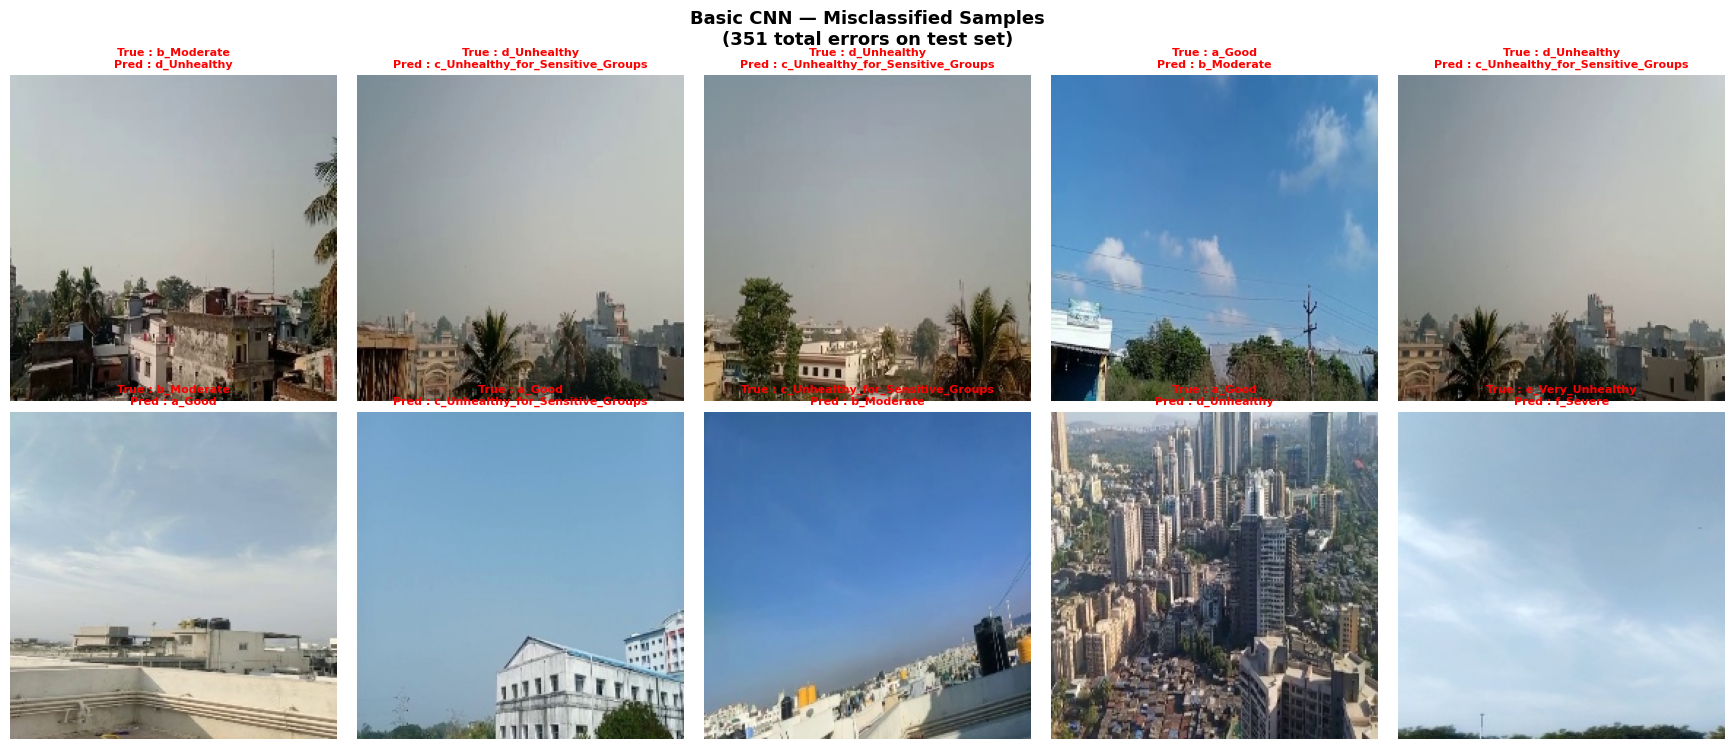

In [104]:
def show_misclassified(misclassified_list, base_path,
                       model_name, n=10, seed=42):
    """Plot n misclassified images with true vs predicted label."""

    # Sample up to n
    import random
    random.seed(seed)
    samples = random.sample(
        misclassified_list,
        min(n, len(misclassified_list))
    )

    cols = 5
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 3.5, rows * 3.8))
    axes = np.array(axes).flatten()

    for i, sample in enumerate(samples):
        # Load original image (no normalization)
        full_path = os.path.join(base_path, sample['filename'])
        img = Image.open(full_path).convert('RGB')
        img = img.resize((224, 224), Image.LANCZOS)

        axes[i].imshow(img)
        axes[i].set_title(
            f"True : {sample['true_label']}\n"
            f"Pred : {sample['pred_label']}",
            fontsize=8,
            color='red' if sample['true_label'] != sample['pred_label'] else 'green',
            fontweight='bold'
        )
        axes[i].axis('off')

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(
        f'{model_name} — Misclassified Samples\n'
        f'({len(misclassified_list)} total errors on test set)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


show_misclassified(misc_cnn, IMAGE_BASE, 'Basic CNN', n=10)

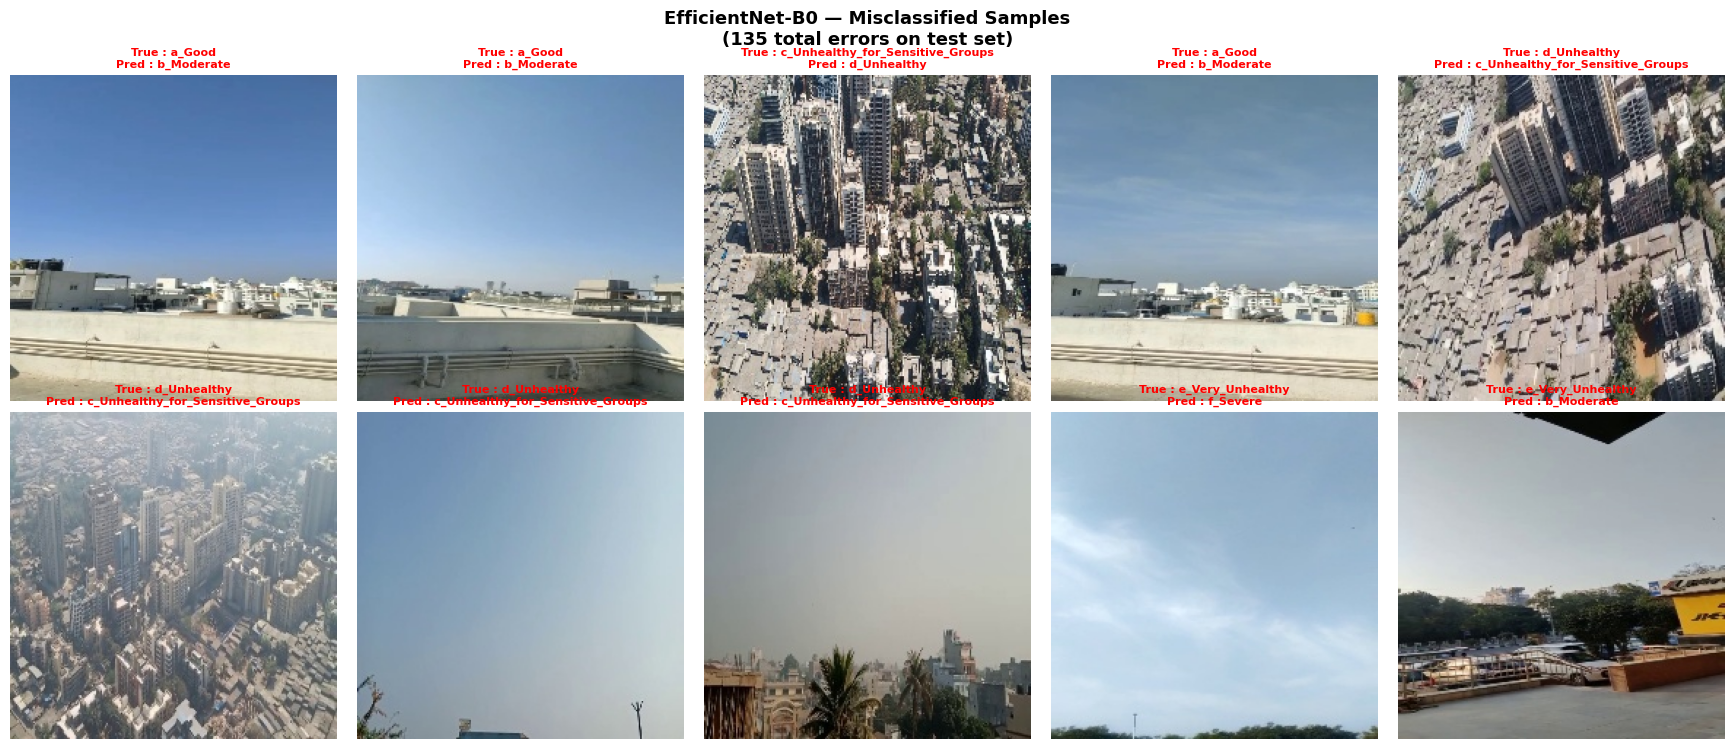

In [105]:
show_misclassified(misc_tl, IMAGE_BASE, 'EfficientNet-B0', n=10)

In [106]:
from collections import Counter

def confusion_pairs(misclassified_list, model_name):
    pairs = Counter()
    for s in misclassified_list:
        pairs[(s['true_label'], s['pred_label'])] += 1

    print(f"\n{'='*50}")
    print(f"  {model_name} — Most Common Confusion Pairs")
    print(f"{'='*50}")
    print(f"  {'True Class':<20} {'Predicted As':<20} {'Count':>5}")
    print(f"  {'-'*45}")
    for (true, pred), count in pairs.most_common(10):
        print(f"  {true:<20} {pred:<20} {count:>5}")


confusion_pairs(misc_cnn, 'Basic CNN')
confusion_pairs(misc_tl,  'EfficientNet-B0')


  Basic CNN — Most Common Confusion Pairs
  True Class           Predicted As         Count
  ---------------------------------------------
  c_Unhealthy_for_Sensitive_Groups d_Unhealthy             51
  a_Good               b_Moderate              40
  b_Moderate           a_Good                  30
  e_Very_Unhealthy     f_Severe                27
  b_Moderate           d_Unhealthy             23
  c_Unhealthy_for_Sensitive_Groups f_Severe                23
  e_Very_Unhealthy     d_Unhealthy             19
  a_Good               d_Unhealthy             18
  b_Moderate           c_Unhealthy_for_Sensitive_Groups    18
  d_Unhealthy          c_Unhealthy_for_Sensitive_Groups    16

  EfficientNet-B0 — Most Common Confusion Pairs
  True Class           Predicted As         Count
  ---------------------------------------------
  a_Good               b_Moderate              33
  d_Unhealthy          c_Unhealthy_for_Sensitive_Groups    14
  c_Unhealthy_for_Sensitive_Groups b_Moderate       

In [107]:
def error_rate_per_class(misclassified_list, test_df,
                         label_encoder, model_name):
    total_per_class = test_df['AQI_Class'].value_counts().to_dict()
    error_per_class = Counter(s['true_label'] for s in misclassified_list)

    rows = []
    for cls in label_encoder.classes_:
        total  = total_per_class.get(cls, 0)
        errors = error_per_class.get(cls, 0)
        rate   = (errors / total * 100) if total > 0 else 0
        rows.append({
            'Class'       : cls,
            'Total Samples': total,
            'Errors'      : errors,
            'Error Rate %': round(rate, 2)
        })

    df_err = pd.DataFrame(rows).sort_values('Error Rate %', ascending=False)
    print(f"\n{'='*50}")
    print(f"  {model_name} — Error Rate per Class")
    print(f"{'='*50}")
    print(df_err.to_string(index=False))
    return df_err


err_cnn = error_rate_per_class(misc_cnn, test_df, le, 'Basic CNN')
err_tl  = error_rate_per_class(misc_tl,  test_df, le, 'EfficientNet-B0')


  Basic CNN — Error Rate per Class
                           Class  Total Samples  Errors  Error Rate %
c_Unhealthy_for_Sensitive_Groups            150     108         72.00
                      b_Moderate            150      77         51.33
                          a_Good            150      76         50.67
                e_Very_Unhealthy            150      50         33.33
                     d_Unhealthy            150      37         24.67
                        f_Severe            150       3          2.00

  EfficientNet-B0 — Error Rate per Class
                           Class  Total Samples  Errors  Error Rate %
                          a_Good            150      34         22.67
c_Unhealthy_for_Sensitive_Groups            150      34         22.67
                     d_Unhealthy            150      26         17.33
                      b_Moderate            150      20         13.33
                e_Very_Unhealthy            150      19         12.67
            

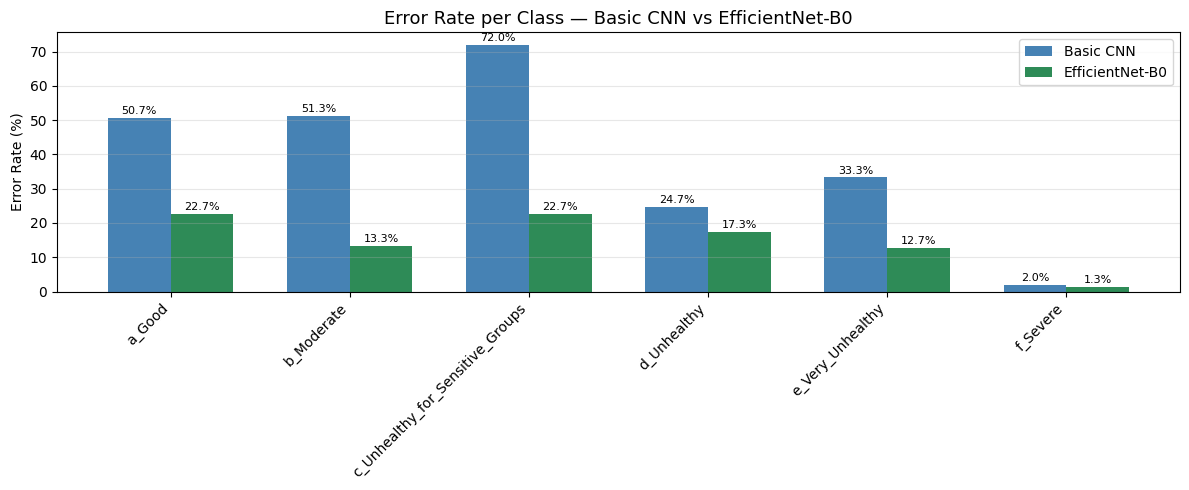

In [108]:
x     = np.arange(len(le.classes_))
width = 0.35

# Align both dataframes to same class order
err_cnn_aligned = err_cnn.set_index('Class').reindex(le.classes_)
err_tl_aligned  = err_tl.set_index('Class').reindex(le.classes_)

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2,
               err_cnn_aligned['Error Rate %'],
               width, label='Basic CNN',       color='steelblue')
bars2 = ax.bar(x + width/2,
               err_tl_aligned['Error Rate %'],
               width, label='EfficientNet-B0', color='seagreen')

ax.set_title('Error Rate per Class — Basic CNN vs EfficientNet-B0',
             fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_ylabel('Error Rate (%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()